In [63]:
import cv2
import numpy as np
import json
from tqdm import tqdm
import polars as pl
from matplotlib import pyplot as plt
from PIL import Image

In [70]:
import os
import numpy as np
import matplotlib.pyplot as plt

def viz_img_keypoints(
    img,
    kpt_xys,
    kpt_classes,
    save_path=None,
    point_size=30,
    alpha=0.9,
    show_legend=False,
    dpi=100,
):
    """
    Visualize N keypoints on an RGB image using matplotlib.
    Ensures saved output has EXACT same shape as input image.

    Args:
        img (np.ndarray): RGB image, shape (H, W, 3)
        kpt_xys (array-like): (N, 2) keypoints in (x, y) pixel coordinates
        kpt_classes (array-like): (N,) integer class labels
        save_path (str | None): path to save visualization
        point_size (int): scatter point size
        alpha (float): point transparency
        show_legend (bool): whether to show legend
        dpi (int): fixed DPI to ensure pixel-perfect output

    Returns:
        fig, ax
    """
    img = np.asarray(img)
    kpt_xys = np.asarray(kpt_xys)
    kpt_classes = np.asarray(kpt_classes)

    assert img.ndim == 3 and img.shape[2] == 3, "img must be HxWx3 RGB"
    assert kpt_xys.shape[0] == kpt_classes.shape[0]
    assert kpt_xys.shape[1] == 2

    H, W = img.shape[:2]

    # ------------------------------------------------------------
    # Pixel-perfect figure: size in inches = pixels / dpi
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(W / dpi, H / dpi), dpi=dpi)
    ax = plt.axes([0, 0, 1, 1])  # fill entire canvas
    ax.axis("off")

    ax.imshow(img, interpolation="nearest")

    # Unique classes → consistent colors
    unique_classes = np.unique(kpt_classes)
    cmap = plt.get_cmap("tab10")
    class_to_color = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

    # Plot per class
    for cls in unique_classes:
        mask = kpt_classes == cls
        if not np.any(mask):
            continue

        pts = kpt_xys[mask]
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=point_size,
            c=[class_to_color[cls]],
            alpha=alpha,
            label=f"class {cls}",
        )

    if show_legend:
        ax.legend(loc="upper right", fontsize=8, frameon=False)

    # ------------------------------------------------------------
    # Save (pixel-perfect)
    # ------------------------------------------------------------
    if save_path is not None:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)

        fig.savefig(
            save_path,
            dpi=dpi,
            pad_inches=0,
            facecolor="black",  # or 'white' depending on preference
        )
        print(f"Saved visualization to: {save_path}")
    else:
        plt.show()

    plt.close(fig)
    return fig, ax


In [71]:
import cv2
import numpy as np
import os

def viz_img_keypoints_cv2(
    img,
    kpt_xys,
    kpt_classes,
    save_path=None,
    point_radius=4, # Replaces point_size (area) with explicit radius
    alpha=0.9,
    show_legend=False,
):
    """
    Visualize N keypoints on an RGB image using OpenCV.
    
    Args:
        img (np.ndarray): RGB image, shape (H, W, 3)
        kpt_xys (array-like): (N, 2) keypoints in (x, y) pixel coordinates
        kpt_classes (array-like): (N,) integer class labels
        save_path (str | None): path to save visualization
        point_radius (int): radius of the scatter points in pixels
        alpha (float): point transparency (0.0 to 1.0)
        show_legend (bool): whether to draw a simple legend overlay
        
    Returns:
        np.ndarray: The visualized RGB image, shape (H, W, 3)
    """
    # 1. Setup Data
    vis = np.asarray(img).copy() # Base image
    overlay = vis.copy()         # Layer for alpha blending
    # kpt_xys = np.asarray(kpt_xys).astype(int)
    kpt_classes = np.asarray(kpt_classes)
    
    h, w = vis.shape[:2]

    # 2. Define Colors (Mimic Tab10 RGB palette)
    # Colors: Blue, Orange, Green, Red, Purple, Brown, Pink, Gray, Olive, Cyan
    palette = [
        (31, 119, 180), (255, 127, 14), (44, 160, 44), (214, 39, 40),
        (148, 103, 189), (140, 86, 75), (227, 119, 194), (127, 127, 127),
        (188, 189, 34), (23, 190, 207)
    ]
    
    unique_classes = np.unique(kpt_classes)
    class_to_color = {
        cls: palette[i % len(palette)] for i, cls in enumerate(unique_classes)
    }

    # 3. Draw Points on Overlay
    for cls in unique_classes:
        mask = kpt_classes == cls
        if not np.any(mask):
            continue
            
        pts = kpt_xys[mask]
        color = class_to_color[cls] # RGB color

        for (x, y) in pts:
            # Check bounds to avoid crashing
            if 0 <= x < w and 0 <= y < h:
                # Filled circle
                cv2.circle(overlay, (x, y), point_radius, color, -1, lineType=cv2.LINE_AA)
                # Optional: Thin white outline for contrast
                cv2.circle(overlay, (x, y), point_radius, (255, 255, 255), 1, lineType=cv2.LINE_AA)

    # 4. Apply Alpha Blending
    # vis = alpha * overlay + (1 - alpha) * vis
    cv2.addWeighted(overlay, alpha, vis, 1 - alpha, 0, vis)

    # 5. Draw Legend (Optional)
    if show_legend:
        # Legend configuration
        pad = 10
        line_h = 25
        box_w = 120
        box_h = pad * 2 + len(unique_classes) * line_h
        
        # Draw semi-transparent white box in top-right
        top_left = (w - box_w, 0)
        bottom_right = (w, box_h)
        
        legend_bg = vis.copy()
        cv2.rectangle(legend_bg, top_left, bottom_right, (255, 255, 255), -1)
        cv2.addWeighted(legend_bg, 0.7, vis, 0.3, 0, vis) # 0.7 opacity for background

        for i, cls in enumerate(unique_classes):
            color = class_to_color[cls]
            cx = w - box_w + pad + 5
            cy = pad + i * line_h + 12
            
            # Draw Color Dot
            cv2.circle(vis, (cx, cy), 6, color, -1, lineType=cv2.LINE_AA)
            
            # Draw Text
            cv2.putText(vis, f"class {cls}", (cx + 15, cy + 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

    # 6. Save or Return
    if save_path is not None:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
        # OpenCV expects BGR for saving, input is assumed RGB
        bgr_vis = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, bgr_vis)
        print(f"Saved visualization to: {save_path}")

    return vis

In [3]:
img = cv2.imread('/home/dangnh36/datasets/ecg/raw/train/1006427285/1006427285-0001.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(1700, 2200, 3)

In [21]:
with open(
    "/home/dangnh36/datasets/ecg/processed/reference_keypoints.json", "r"
) as f:
    ref_kpts = json.load(f)
ref_kpt_xys = np.array(list(ref_kpts.values()))
ref_kpt_names = list(ref_kpts.keys())
len(ref_kpt_names), ref_kpt_xys.shape

(2422, (2422, 2))

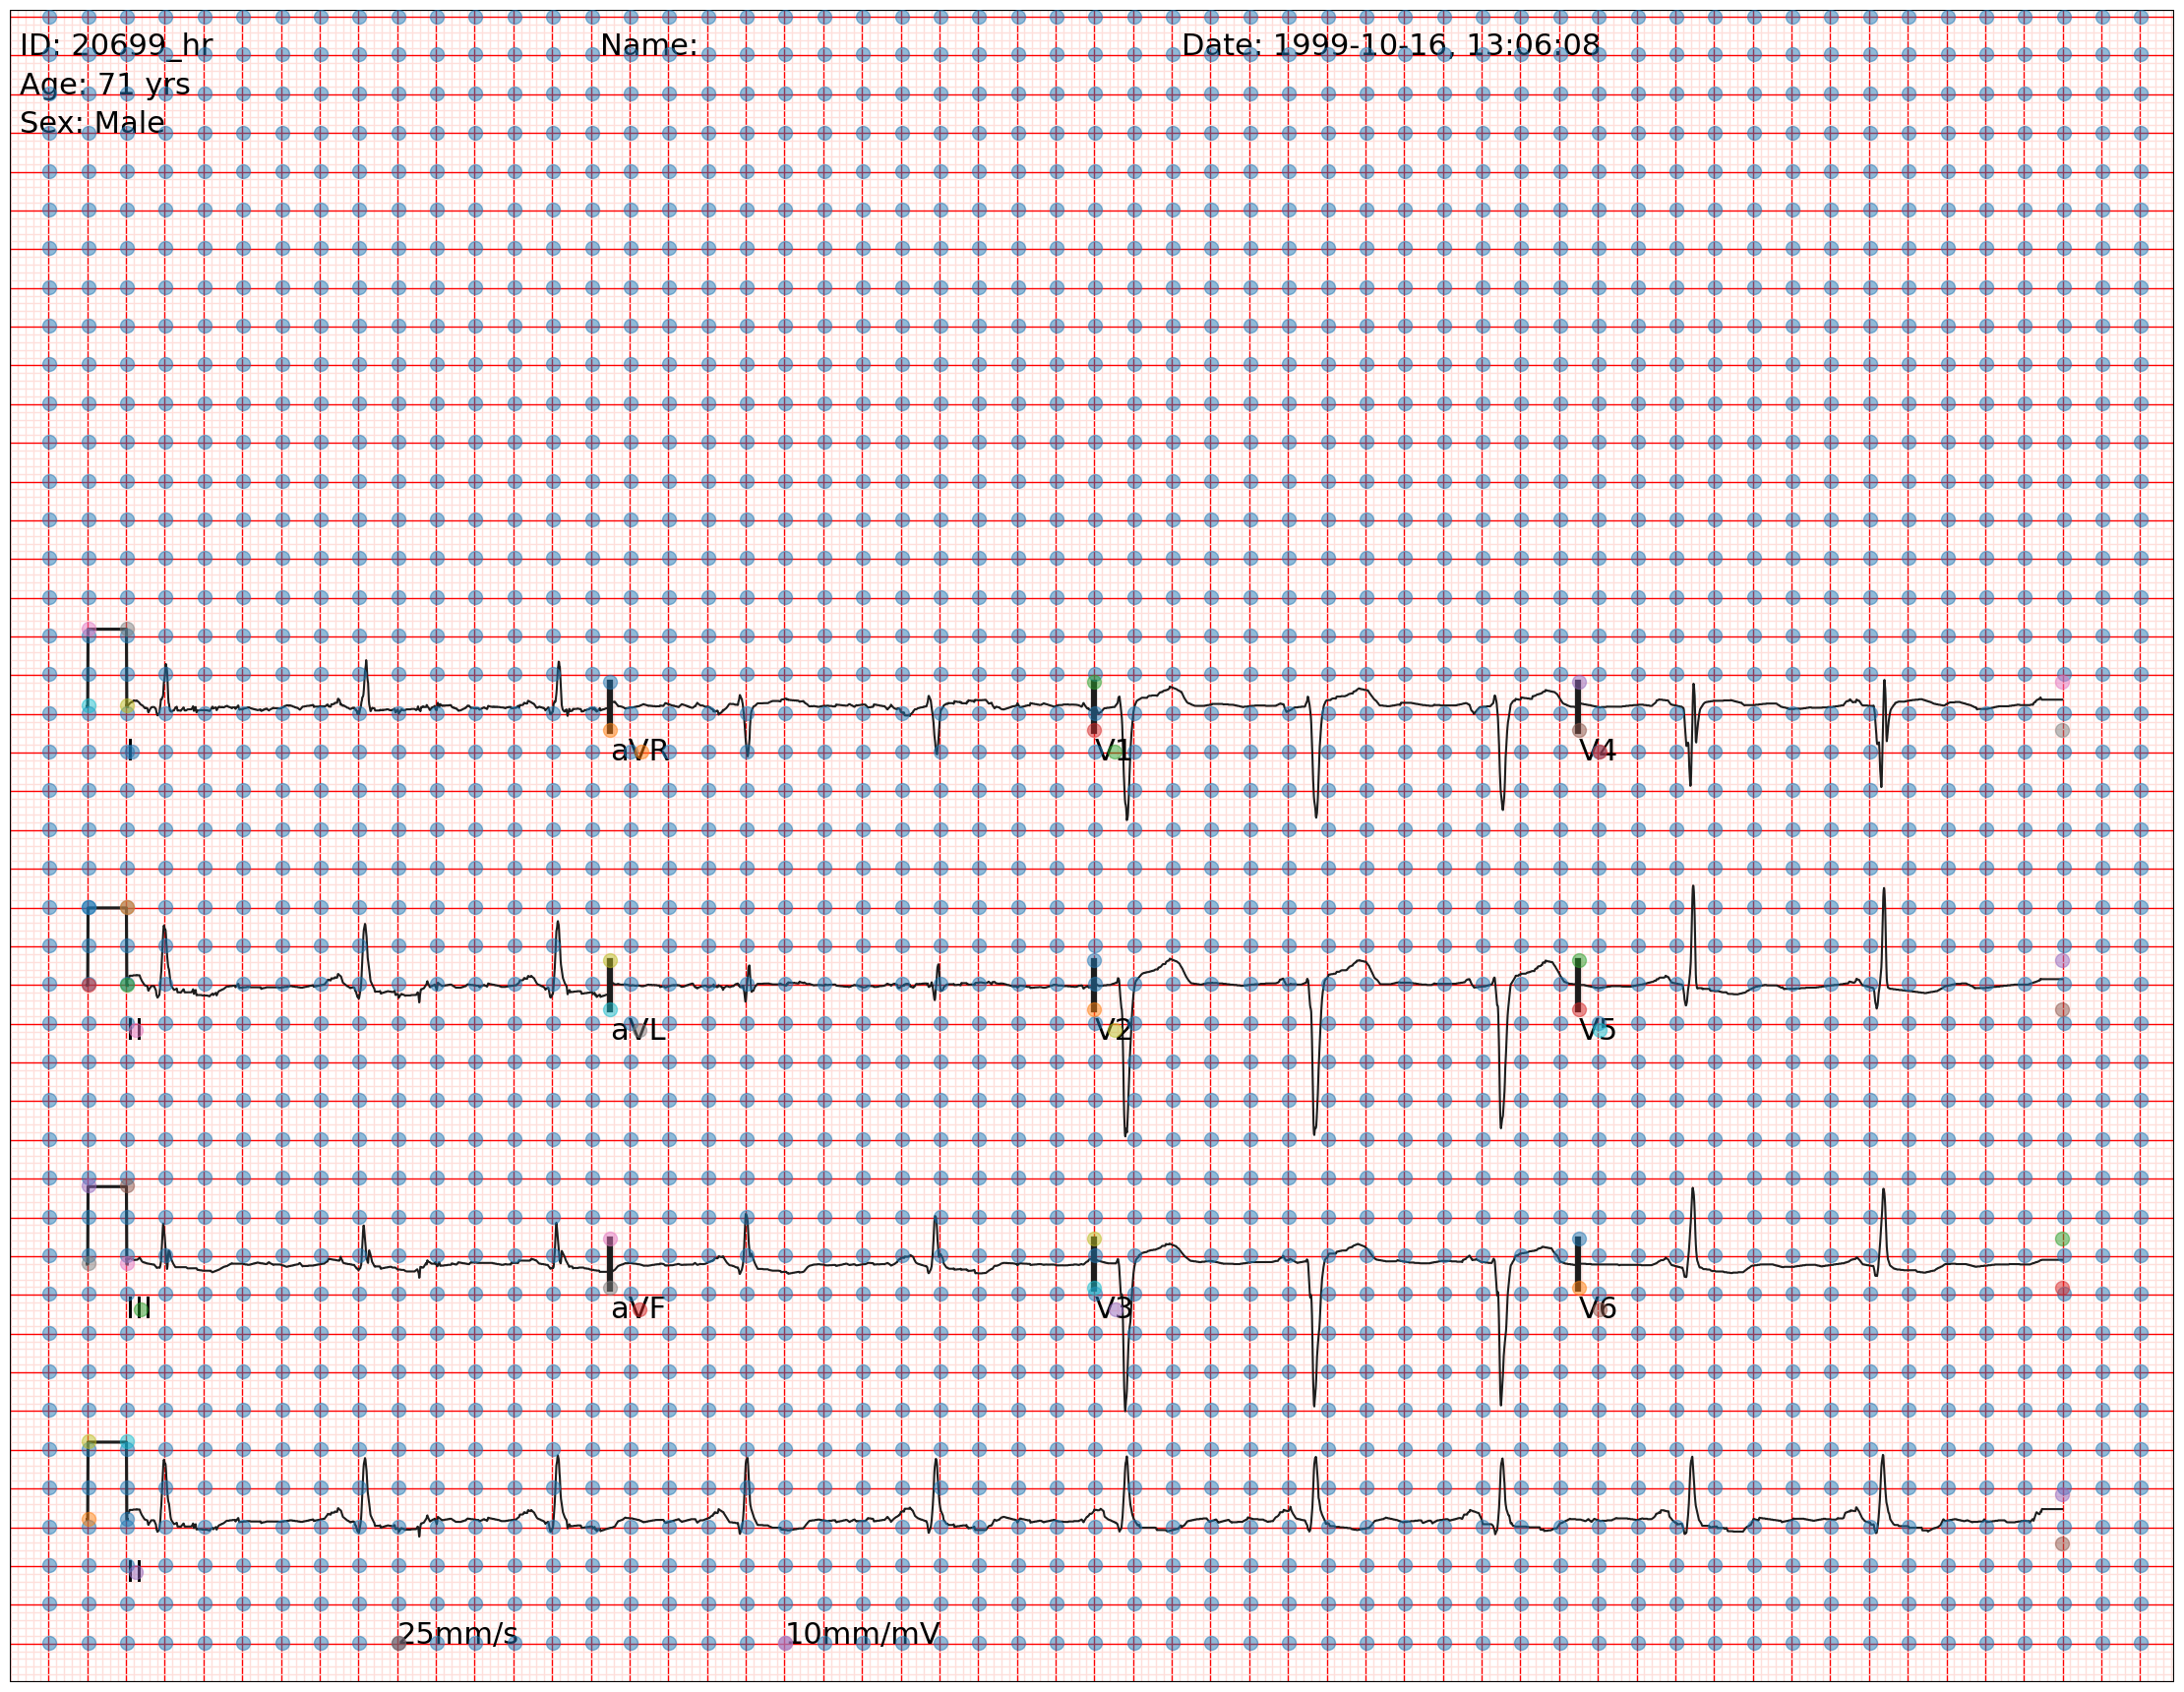

(2422, 2) int64


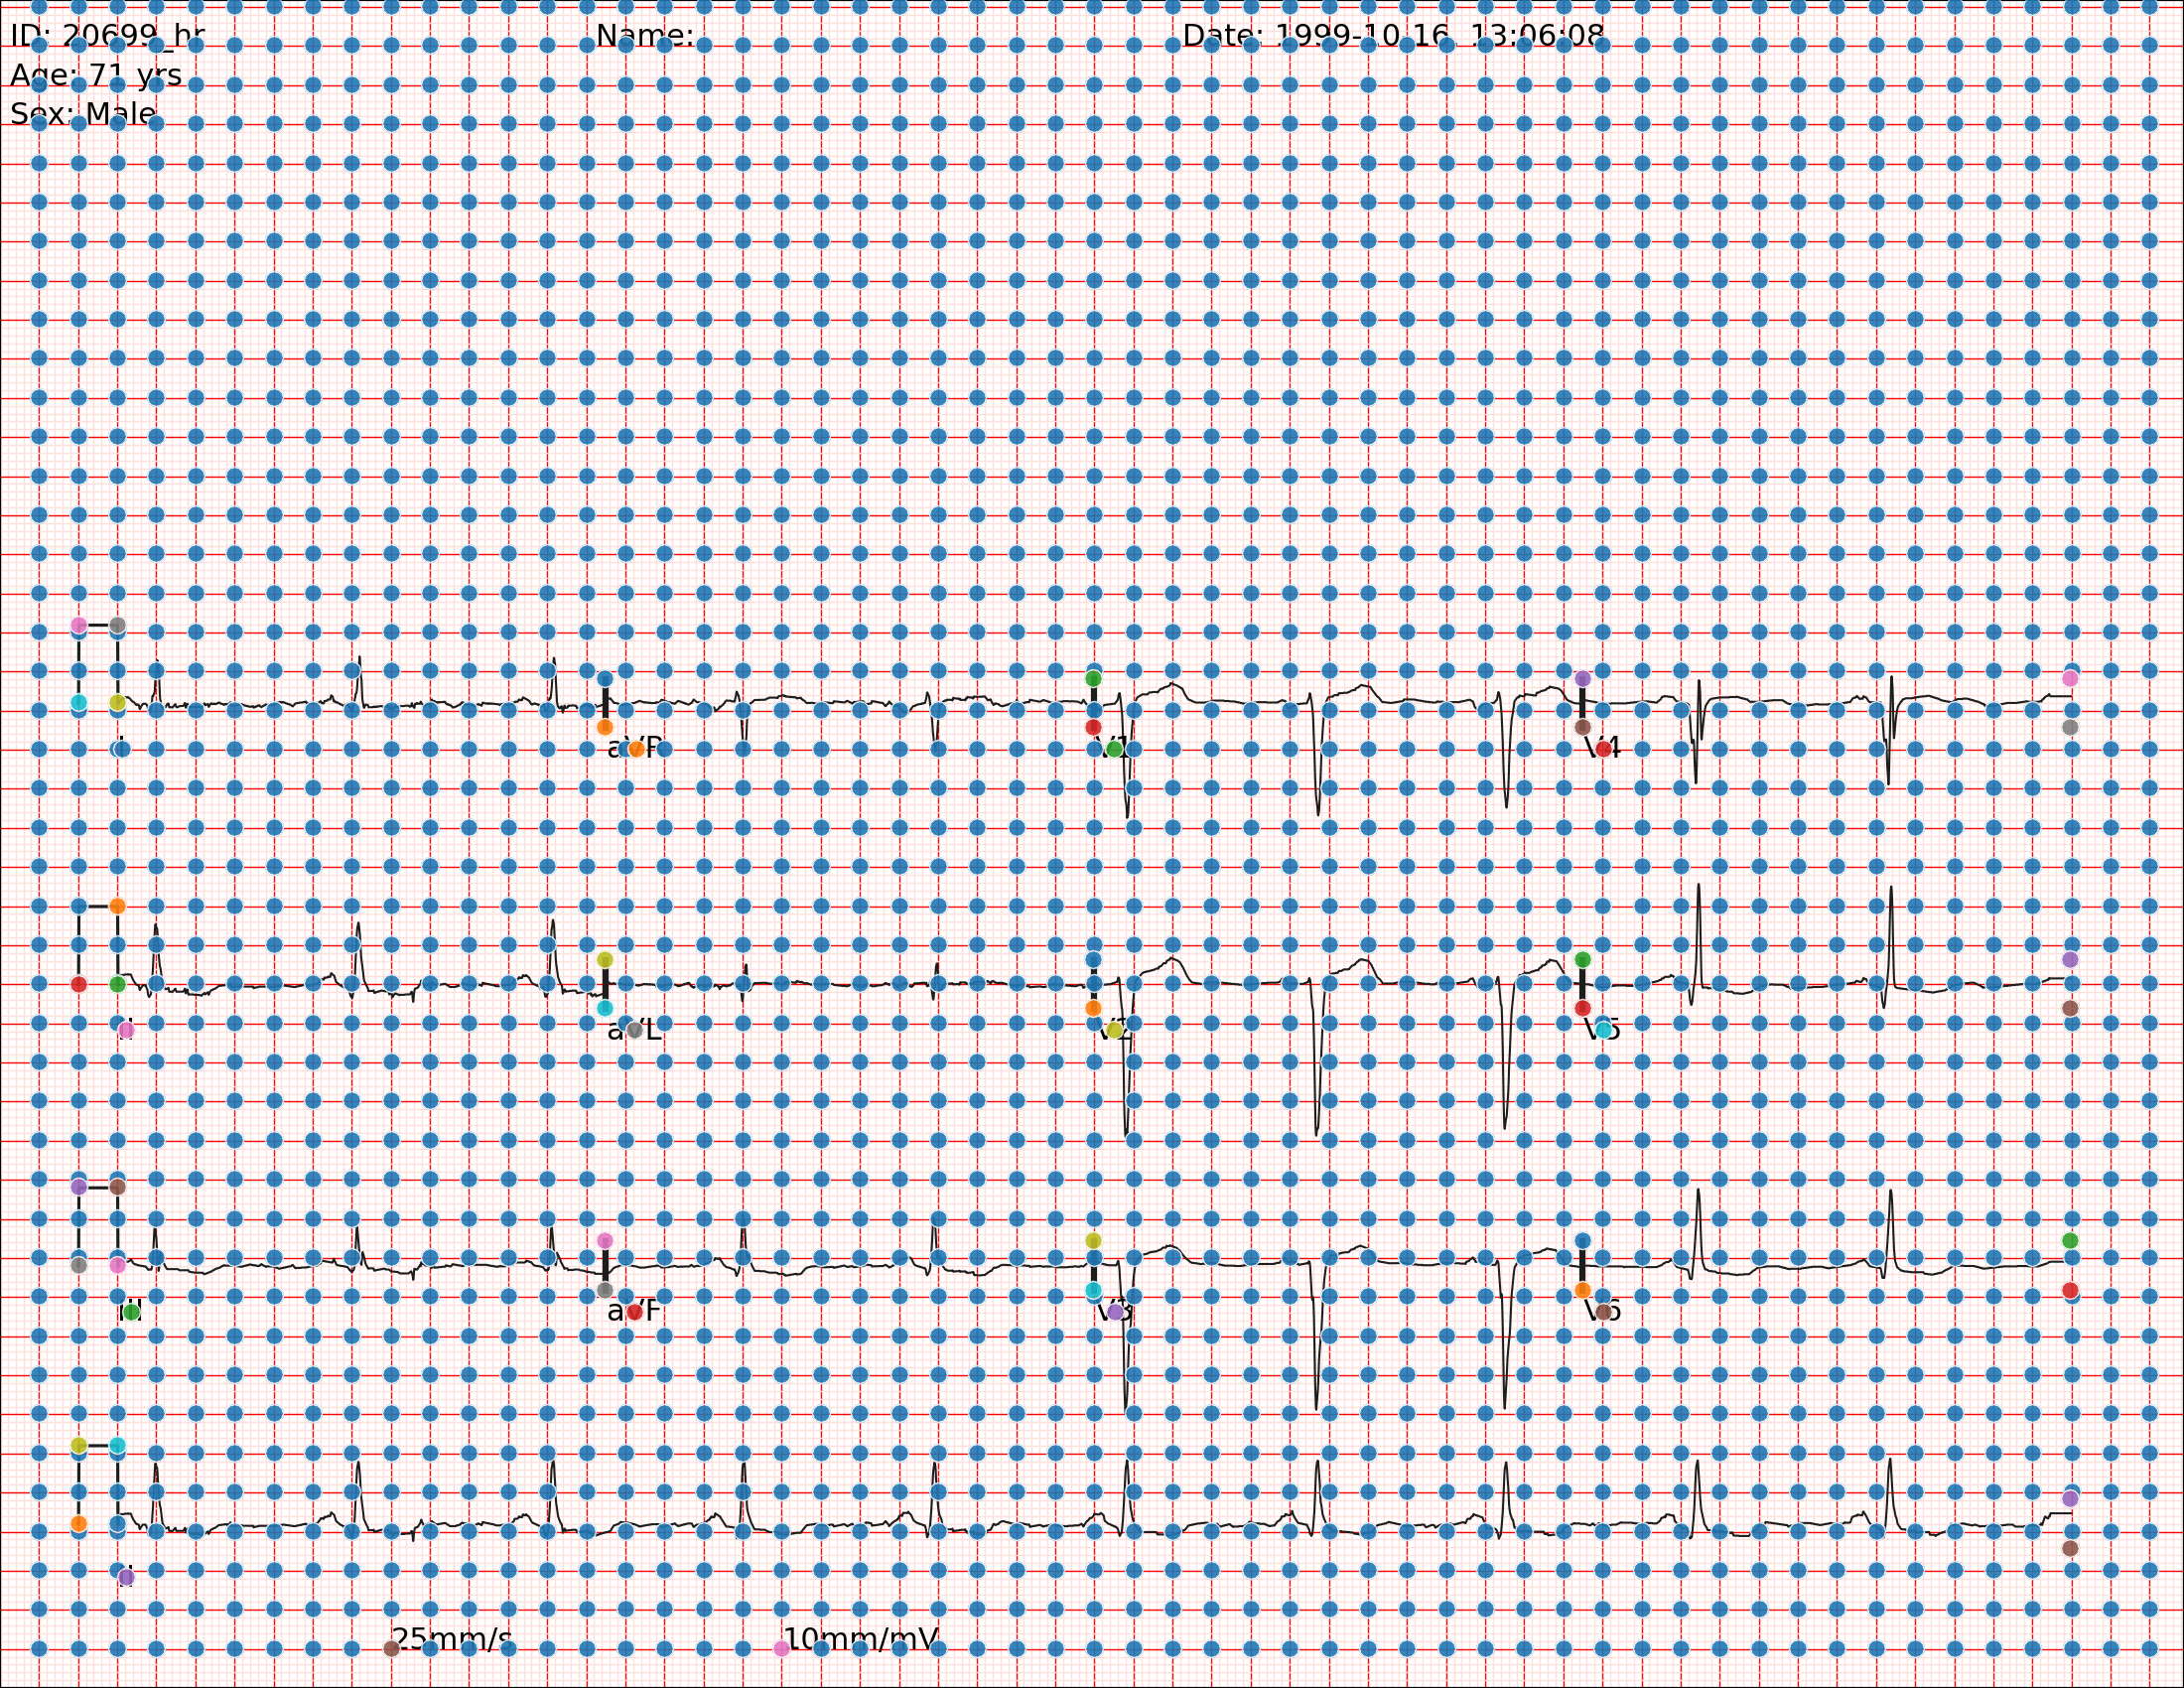

In [94]:
viz_kpt_xys = ref_kpt_xys.copy()
viz_kpt_xys = viz_kpt_xys + np.array([[0.5, -0.5]])
# viz_kpt_xys = viz_kpt_xys - 0.5
viz_kpt_xys = viz_kpt_xys.astype(int)
# viz_kpt_xys = np.round(viz_kpt_xys).astype(int)

# print('CHECK', np.sum(np.abs(ref_kpt_xys.astype(int) - np.round(ref_kpt_xys - 0.5))))

viz_img_keypoints(
    img,
    viz_kpt_xys,
    kpt_classes = [0] * 2365 + list(range(57)),
    save_path=None,
    point_size=101,
    alpha=0.5,
    show_legend=False,
)

print(viz_kpt_xys.shape, viz_kpt_xys.dtype)
viz = viz_img_keypoints_cv2(
    img,
    viz_kpt_xys,
    kpt_classes = [0] * 2365 + list(range(57)),
    save_path=None,
    point_radius=9,
    alpha=0.9,
    show_legend=False,
)
display(Image.fromarray(viz))